![](https://github.com/destination-earth/DestinE-DataLake-Lab/blob/main/img/DestinE-banner.jpg?raw=true)


# Tutorial to access the impact-sector application output of HydroLand

**Author**: EUMETSAT / UFZ <br>
**Copyright**: 2026 EUMETSAT <br>
**Licence**: MIT <br>
**Modified by**: Jeisson Leal

<div class="alert alert-block alert-warning">
<b> Prerequisites: </b>
<li> For Data access : <a href="https://platform.destine.eu/"> DestinE user account and access to restricted datasets</a> </li>
<li> Installation of Python packages <code class="python">destinelab requests tqdm xarray netCDF4 cartopy matplotlib</code></li>
</div>

This notebook demonstrates how to search for, inspect, download, and plot HydroLand application output from the Destination Earth Data Lake using the HDA/STAC REST API.

The basic sequence is:

1. authenticate with a DestinE Service Platform account,
2. inspect the HydroLand STAC collection metadata,
3. search for matching STAC items using date, spatial, and sorting filters,
4. inspect the assets attached to the returned items,
5. download NetCDF assets and
6. open and plot one downloaded HydroLand file as a quick sanity check.

In STAC terminology, the **collection** describes the dataset as a whole, **items** describe individual spatiotemporal products, and **assets** are the actual files that can be downloaded.

## Import the relevant modules

The notebook uses `destinelab` Python library for authentication, `json` for displaying API responses, and `xarray` for opening downloaded NetCDF files.


In [1]:
import glob
import json
import requests
from getpass import getpass

import xarray as xr
import destinelab as deauth

from pathlib import Path
from tqdm import tqdm
from urllib3.util.retry import Retry

## Define constants for the API URLs

`COLLECTION_ID` is the unique Data Lake identifier for the HydroLand collection used in this example. The remaining constants build the standard HDA/STAC endpoints used to discover the collection and search its items.

`REQUEST_TIMEOUT`, `REQUEST_RETRIES`, and `DOWNLOAD_CHUNK_SIZE` control network behaviour. Most users can keep these defaults, but increasing the timeout can help on slower connections.

In [3]:
# Define the collection to be used
COLLECTION_ID = "EO.UFZ.DAT.HYDROLAND"

# Core API
HDA_API_URL = "https://hda.data.destination-earth.eu"

# STAC API
STAC_API_URL = f"{HDA_API_URL}/stac/v2"
COLLECTIONS_URL = f"{STAC_API_URL}/collections"
COLLECTION_BY_ID_URL = f"{COLLECTIONS_URL}/{COLLECTION_ID}"
COLLECTION_ITEMS_URL = f"{COLLECTIONS_URL}/{COLLECTION_ID}/items"
SEARCH_URL = f"{STAC_API_URL}/search"

# Request settings
REQUEST_TIMEOUT = 30    # seconds
REQUEST_RETRIES = 3
DOWNLOAD_CHUNK_SIZE = 1_048_576  # 1 MB

## Authenticate

HydroLand application output is restricted, so the search and download requests need an authorization header. The next cell asks for your DestinE Service Platform username and password, obtains an access token with `destinelab`, and stores it in `auth_headers` for the API calls below.

In [ ]:
DESP_USERNAME = input("Please input your DESP username or email: ")
DESP_PASSWORD = getpass("Please input your DESP password: ")

auth = deauth.AuthHandler(DESP_USERNAME, DESP_PASSWORD)
access_token = auth.get_token()
if access_token is not None:
    print("DEDL/DESP Access Token Obtained Successfully")
else:
    print("Failed to Obtain DEDL/DESP Access Token")

auth_headers = {"Authorization": f"Bearer {access_token}"}

## Discover data - authenticated

Once authenticated, we first request the collection metadata. This response does not contain the data files themselves; it describes the HydroLand collection, including its title, temporal and spatial coverage, links, license, and available query metadata.

This is a useful first check before searching, because it confirms that the collection identifier is valid and that your account can access the collection.

In [ ]:
response = requests.get(COLLECTION_BY_ID_URL, headers=auth_headers)

print(json.dumps(response.json(), indent=4))

## Search

The next step is to search the HydroLand collection for matching STAC items. A search request does not download data yet; it returns metadata records and download links for the files that match the selected filters.

The search body below contains the main user-editable filters:

- `SEARCH_DATETIME`: ISO-8601 time interval in UTC, written as `start/end`. Change this to select the period you want.
- `SEARCH_BBOX`: spatial bounding box as `[west_lon, south_lat, east_lon, north_lat]` in decimal degrees. The current value searches globally.
- `SEARCH_LIMIT`: maximum number of items returned per API page.
- `SEARCH_SORTBY`: result ordering. The current setting returns newest matching items first.

The collection covers **1990-01-01 to 2049-12-31**. The API response is a STAC FeatureCollection: each entry in `features` is one item, and each item contains metadata plus `assets` with downloadable files.

In [ ]:
# User-editable search filters.
# Time interval in UTC: "start/end". Short periods are safer for first tests.
SEARCH_DATETIME = "2040-01-01T00:00:00Z/2040-12-31T00:00:00Z"

# Bounding box: [west_lon, south_lat, east_lon, north_lat]. This value is global.
SEARCH_BBOX = [-180, -90, 180, 90]

# Maximum items per API page; each month has approximately two items (mhm + mrm).
SEARCH_LIMIT = 100

# Return newest matching items first.
SEARCH_SORTBY = [{"field": "datetime", "direction": "desc"}]

BODY = {
    "collections": [COLLECTION_ID],
    "datetime": SEARCH_DATETIME,
    "bbox": SEARCH_BBOX,
    "sortby": SEARCH_SORTBY,
    "limit": SEARCH_LIMIT,
}

response = requests.request(
    method="POST",
    url=SEARCH_URL,
    headers=auth_headers,
    json=BODY,
)
print(json.dumps(response.json(), indent=4))

### List all available items for the period

The first search response is limited by `SEARCH_LIMIT`. The helper function `fetch_all_items()` sends the same search request and follows the STAC `next` pagination links automatically, so you see every matching item even if the API splits the result across several pages.

The printed summary shows the item start date, the driving climate model stored in `internal_fdp:model`, the HydroLand data type, the experiment, and the file assets attached to each item.

In [9]:
all_items = []
while True:
    page = requests.request(
        method="POST",
        url=SEARCH_URL,
        headers=auth_headers,
        json=BODY,
    ).json()
    features = page.get("features", [])
    all_items.extend(features)

    next_link = next(
        (lnk for lnk in page.get("links", []) if lnk.get("rel") == "next"),
        None,
    )
    if not next_link or not next_link.get("body"):
        break
    current_body = next_link["body"]



print(f"Total items found: {len(all_items)}\n")
for item in all_items:
    props = item["properties"]
    assets = [k for k in item.get("assets", {}) if k != "downloadLink"]
    print(
        f"  {props.get('start_datetime', '')[:10]}  "
        f"model={props.get('internal_fdp:model', '')}  "
        f"type={props.get('internal_fdp:collection_data_type', '')}  "
        f"exp={props.get('internal_fdp:experiment', '')}  "
        f"files={assets}"
    )

Total items found: 24

  2040-12-01  model=IFS-NEMO  type=mrm  exp=SSP3-7.0  files=['2040_12_01_T00_00_to_2040_12_31_T23_00_mRM_Fluxes_States.nc']
  2040-12-01  model=IFS-NEMO  type=mhm  exp=SSP3-7.0  files=['2040_12_01_to_2040_12_31_daily_mHM_Fluxes_States.nc']
  2040-11-01  model=IFS-NEMO  type=mrm  exp=SSP3-7.0  files=['2040_11_01_T00_00_to_2040_11_30_T23_00_mRM_Fluxes_States.nc']
  2040-11-01  model=IFS-NEMO  type=mhm  exp=SSP3-7.0  files=['2040_11_01_to_2040_11_30_daily_mHM_Fluxes_States.nc']
  2040-10-01  model=IFS-NEMO  type=mrm  exp=SSP3-7.0  files=['2040_10_01_T00_00_to_2040_10_31_T23_00_mRM_Fluxes_States.nc']
  2040-10-01  model=IFS-NEMO  type=mhm  exp=SSP3-7.0  files=['2040_10_01_to_2040_10_31_daily_mHM_Fluxes_States.nc']
  2040-09-01  model=IFS-NEMO  type=mrm  exp=SSP3-7.0  files=['2040_09_01_T00_00_to_2040_09_30_T23_00_mRM_Fluxes_States.nc']
  2040-09-01  model=IFS-NEMO  type=mhm  exp=SSP3-7.0  files=['2040_09_01_to_2040_09_30_daily_mHM_Fluxes_States.nc']
  2040-08-01  mod

## Download - one selected file

This is the recommended download path for this notebook. It downloads individual NetCDF assets using the signed asset URLs returned by the Data Lake.

The listing above shows **every** file available for the search period, but a quick start does not need all of them. **In this example we download only one file**, the January 2040 mRM output `2040_01_01_T00_00_to_2040_01_31_T23_00_mRM_Fluxes_States.nc`.

`TARGET_FILE` controls the selection: set it to any file name printed by the listing cell above to fetch a different one, or set it to `None` to download every asset returned by the search.

Files are written under a directory named after `COLLECTION_ID`, grouped by item id. Existing files are skipped by default because `existing_policy="skip"`; change this to `"overwrite"` only if you intentionally want to replace local files.

In [ ]:
# Name of the single file to download. It must be one of the file names printed by
# the listing cell above. Set TARGET_FILE = None to download all matching assets.
TARGET_FILE = "2040_01_01_T00_00_to_2040_01_31_T23_00_mRM_Fluxes_States.nc"

if TARGET_FILE is None:
    selected_items = all_items
    download_items = all_items
else:
    # The STAC item that owns TARGET_FILE, kept whole because the optional
    # archive cell below needs its downloadLink asset.
    selected_items = [item for item in all_items if TARGET_FILE in item.get("assets", {})]
    if not selected_items:
        raise ValueError(
            f"{TARGET_FILE!r} is not among the search results. "
            "Use one of the file names printed by the listing cell above."
        )
    # The same item trimmed to that one asset, so exactly one file is downloaded.
    download_items = [
        {**item, "assets": {TARGET_FILE: item["assets"][TARGET_FILE]}}
        for item in selected_items
    ]

for asset in download_items:
    url = next(iter(asset["assets"].values()))["href"]

    local_file = url.split("/internal_fdp/", 1)[1]
    local_file = Path(local_file)
    local_file.parent.mkdir(parents=True, exist_ok=True)

    response = requests.get(url, stream=True, headers=auth_headers)
    response.raise_for_status()

    total_size = int(response.headers.get("Content-Length", 0))

    with open(local_file, "wb") as f, tqdm(
        total=total_size,
        unit="B",
        unit_scale=True,
        desc=f"Downloading {local_file}",
    ) as progress_bar:
        for chunk in response.iter_content(chunk_size=DOWNLOAD_CHUNK_SIZE):
            if chunk:
                f.write(chunk)
                progress_bar.update(len(chunk))


## Display the downloaded file

The downloaded NetCDF file can be opened directly with `xarray`. The cell below looks inside the `COLLECTION_ID` folder for the file named in `TARGET_FILE` and falls back to the first `.nc` file it finds if that name is not present locally.

If you downloaded several files in earlier runs, change `local_file` after the `nc_files` list is created to inspect a specific one.

In [11]:
nc_files = sorted(glob.glob(f"{COLLECTION_ID}/**/*.nc", recursive=True))
target_matches = [f for f in nc_files if Path(f).name == TARGET_FILE]

if target_matches or nc_files:
    local_file = (target_matches or nc_files)[0]
    print(f"Opening: {local_file}")
    ds = xr.open_dataset(local_file)
    print(ds)
else:
    print("No .nc files found. Run the download cell above first.")

Opening: EO.UFZ.DAT.HYDROLAND/EO.UFZ.DAT.HYDROLAND_20400101T000000_20400131T230000__IFS-NEMO__SSP3-7.0__generation-2__projections__realization-1__mrm/2040_01_01_T00_00_to_2040_01_31_T23_00_mRM_Fluxes_States.nc
<xarray.Dataset> Size: 120GB
Dimensions:  (time: 744, lat: 2800, lon: 7200)
Coordinates:
  * time     (time) datetime64[ns] 6kB 2040-01-01 ... 2040-01-31T23:00:00
  * lat      (lat) float64 22kB 83.97 83.92 83.88 83.82 ... -55.88 -55.93 -55.98
  * lon      (lon) float64 58kB -180.0 -179.9 -179.9 ... 179.9 179.9 180.0
Data variables:
    Qrouted  (time, lat, lon) float64 120GB ...
Attributes: (12/22)
    project:            Climate DT project
    setup_description:  model run for Climate DT project
    simulation_type:    simulation
    Conventions:        tbd
    contact:            Stephan Thober (email: stephan.thober@ufz.de
    mRM_details:        Helmholtz Center for Environmental Research - UFZ, De...
    ...                 ...
    class:              d1
    realization:   

## Plot the downloaded data

This final cell is a quick visual sanity check for the downloaded data. By default it plots a western Europe zoom of the first time step of `Qrouted`; if `Qrouted` is not present, it falls back to the first variable with `lat`/`lon` dimensions.

Edit `LON_MIN`, `LON_MAX`, `LAT_MIN`, and `LAT_MAX` to inspect a different region. The inset map shows where the zoomed region is located on the globe.


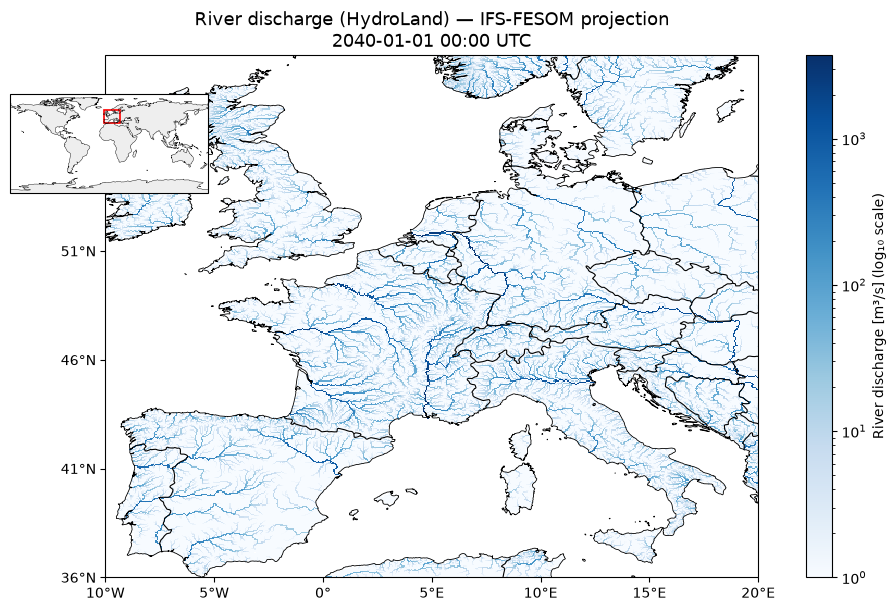

In [12]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.mpl.ticker as cticker
import matplotlib.colors as colors
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np

# Zoom to western Europe -- edit these to look at a different region.
LON_MIN, LON_MAX, LAT_MIN, LAT_MAX = -10, 20, 36, 60

var_name = "Qrouted" if "Qrouted" in ds.data_vars else list(ds.data_vars)[0]
da0 = ds[var_name].isel(time=0) if "time" in ds[var_name].dims else ds[var_name]
timestamp = str(da0.time.values)[:16].replace("T", " ") if "time" in da0.coords else ""

# Crop before plotting so a global, high-resolution grid still renders fast.
lat_slice = slice(LAT_MAX, LAT_MIN) if da0.lat[0] > da0.lat[-1] else slice(LAT_MIN, LAT_MAX)
field = da0.sel(lat=lat_slice, lon=slice(LON_MIN, LON_MAX)).where(lambda x: x > 0)

proj = ccrs.PlateCarree()
fig, ax = plt.subplots(figsize=(9, 6), subplot_kw={"projection": proj}, constrained_layout=True)
ax.set_extent([LON_MIN, LON_MAX, LAT_MIN, LAT_MAX], crs=proj)

mesh = field.plot.pcolormesh(
    ax=ax, transform=proj, cmap="Blues",
    norm=colors.LogNorm(vmin=1, vmax=float(field.max())),
    add_colorbar=False,
)
ax.coastlines(resolution="10m", linewidth=0.6)
ax.add_feature(cfeature.BORDERS, linewidth=0.8)
ax.xaxis.set_major_formatter(cticker.LongitudeFormatter())
ax.yaxis.set_major_formatter(cticker.LatitudeFormatter())
ax.set_xticks(np.arange(LON_MIN, LON_MAX + 1, 5), crs=proj)
ax.set_yticks(np.arange(LAT_MIN, LAT_MAX + 1, 5), crs=proj)
ax.set_xlabel("")
ax.set_ylabel("")
ax.set_title(
    f"River discharge (HydroLand) \u2014 IFS-FESOM projection\n{timestamp} UTC",
    fontsize=13,
)

cbar = fig.colorbar(mesh, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("River discharge [m\u00b3/s] (log\u2081\u2080 scale)")

# Small locator globe so it's clear this is a zoom-in, not the whole domain.
axins = fig.add_axes([0.02, 0.66, 0.22, 0.22], projection=proj)
axins.set_global()
axins.add_feature(cfeature.LAND, facecolor="#eee", zorder=0)
axins.coastlines(resolution="110m", linewidth=0.3)
axins.add_patch(mpatches.Rectangle(
    (LON_MIN, LAT_MIN), LON_MAX - LON_MIN, LAT_MAX - LAT_MIN,
    edgecolor="red", facecolor="none", linewidth=1.2, transform=proj,
))
axins.set_xticks([])
axins.set_yticks([])

plt.show()